<a href="https://colab.research.google.com/github/zgrkrtl/AI-Cybersecurity-Lab/blob/main/NSL_KDD_Dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

NSL-KDD-Dataset Preprocessing

Import Data

In [ ]:
import pandas as pd
from google.colab import drive
drive.mount('/content/drive')
df = pd.read_csv('/content/drive/MyDrive/CyberSecurityAIDataset/NSL-KDD-Dataset-master/KDDTrain+.txt', header=None)

Check Data

In [8]:
print(df.shape)
print(df.head())
print(df[41].value_counts())

(125973, 43)
   0    1         2   3    4     5   6   7   8   9   ...    33    34    35  \
0   0  tcp  ftp_data  SF  491     0   0   0   0   0  ...  0.17  0.03  0.17   
1   0  udp     other  SF  146     0   0   0   0   0  ...  0.00  0.60  0.88   
2   0  tcp   private  S0    0     0   0   0   0   0  ...  0.10  0.05  0.00   
3   0  tcp      http  SF  232  8153   0   0   0   0  ...  1.00  0.00  0.03   
4   0  tcp      http  SF  199   420   0   0   0   0  ...  1.00  0.00  0.00   

     36    37    38    39    40       41  42  
0  0.00  0.00  0.00  0.05  0.00   normal  20  
1  0.00  0.00  0.00  0.00  0.00   normal  15  
2  0.00  1.00  1.00  0.00  0.00  neptune  19  
3  0.04  0.03  0.01  0.00  0.01   normal  21  
4  0.00  0.00  0.00  0.00  0.00   normal  21  

[5 rows x 43 columns]
41
normal             67343
neptune            41214
satan               3633
ipsweep             3599
portsweep           2931
smurf               2646
nmap                1493
back                 956
teardrop  

Edit Column Names and remove difficulty score column

In [9]:
columns = [
    'duration','protocol_type','service','flag','src_bytes','dst_bytes',
    'land','wrong_fragment','urgent','hot','num_failed_logins','logged_in',
    'num_compromised','root_shell','su_attempted','num_root','num_file_creations',
    'num_shells','num_access_files','num_outbound_cmds','is_host_login',
    'is_guest_login','count','srv_count','serror_rate','srv_serror_rate',
    'rerror_rate','srv_rerror_rate','same_srv_rate','diff_srv_rate',
    'srv_diff_host_rate','dst_host_count','dst_host_srv_count',
    'dst_host_same_srv_rate','dst_host_diff_srv_rate','dst_host_same_src_port_rate',
    'dst_host_srv_diff_host_rate','dst_host_serror_rate','dst_host_srv_serror_rate',
    'dst_host_rerror_rate','dst_host_srv_rerror_rate','label','difficulty'
]

df.columns = columns
df = df.drop('difficulty', axis=1)

Simplify attack types

In [10]:
df['label'] = df['label'].apply(lambda x: 0 if x== 'normal' else 1)
# 0=normal, 1=attack

Encode categorical columns

In [11]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
for col in ['protocol_type', 'service', 'flag']:
  df[col] = le.fit_transform(df[col])

Split features and label

In [12]:
X = df.drop('label', axis=1).values
y= df['label'].values

Normalize

In [14]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X = scaler.fit_transform(X)

Train/Test split

In [15]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

Convert To Tensor

In [16]:
import torch

X_train = torch.FloatTensor(X_train)
X_test = torch.FloatTensor(X_test)
y_train = torch.FloatTensor(y_train).unsqueeze(1)
y_test = torch.FloatTensor(y_test).unsqueeze(1)

In [18]:
print(X_train.shape)
print(y_train.shape)

torch.Size([100778, 41])
torch.Size([100778, 1])


Create Pytorch Model

In [19]:
import torch
from torch import nn

device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

In [20]:
import torch
import torch.nn as nn

class IntrusionDetector(nn.Module):
    def __init__(self):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(41, 64),
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.network(x)

model = IntrusionDetector()
print(model)

IntrusionDetector(
  (network): Sequential(
    (0): Linear(in_features=41, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=32, bias=True)
    (3): ReLU()
    (4): Linear(in_features=32, out_features=1, bias=True)
    (5): Sigmoid()
  )
)


Training

In [21]:
criterion = nn.BCELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

epochs = 20
for epoch in range(epochs):
  model.train()
  optimizer.zero_grad()
  outputs = model(X_train)
  loss = criterion(outputs, y_train)
  loss.backward()
  optimizer.step()

  if(epoch+1) % 5 == 0:
    print(f'Epoch {epoch+1}/{epochs}, Loss: {loss.item():.4f}')

Epoch 5/20, Loss: 0.6541
Epoch 10/20, Loss: 0.6196
Epoch 15/20, Loss: 0.5778
Epoch 20/20, Loss: 0.5277


Testing

In [22]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

model.eval()
with torch.no_grad():
  predictions = model(X_test)
  predicted_labels = (predictions >= 0.5).float()

y_true = y_test.numpy()
y_pred = predicted_labels.numpy()

print(classification_report(y_true, y_pred, target_names=['Normal', 'Attack']))
print("Confusion Matrix:")
print(confusion_matrix(y_true, y_pred))



              precision    recall  f1-score   support

      Normal       0.91      0.95      0.93     13422
      Attack       0.94      0.89      0.91     11773

    accuracy                           0.92     25195
   macro avg       0.92      0.92      0.92     25195
weighted avg       0.92      0.92      0.92     25195

Confusion Matrix:
[[12716   706]
 [ 1301 10472]]


Visualize

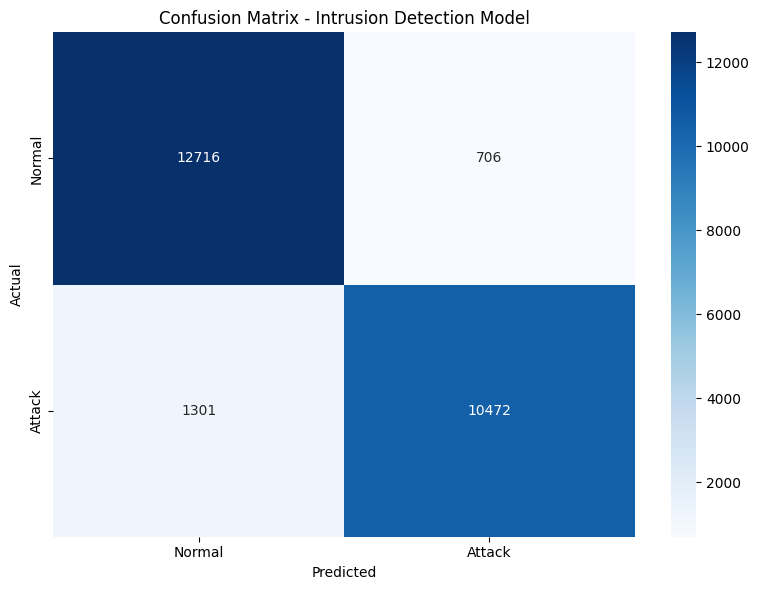

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal', 'Attack'],
            yticklabels=['Normal', 'Attack'])
plt.title('Confusion Matrix - Intrusion Detection Model')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig('confusion_matrix.png')
plt.show()